# Point Scan EDS Comparison with ROI Context

This notebook compares representative SEM-EDS point spectra from selected regions of interest (ROIs) to support interpretation of clustering results.

The goal is to:
- identify characteristic spectral features of each region
- distinguish zinc-rich and cadmium-rich compositions
- provide chemical validation of spatial clustering results

In [40]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from PIL import Image

plt.rcParams["figure.dpi"] = 120

In [41]:
# Paths
RAW_BASE = Path("data_raw/Point Scans")
OUT_BASE = Path("data_processed/point_scans")
FIG_DIR = OUT_BASE / "figures"

FOLDERS = [
    "CS diffusion",
    "Gel and Bioplastic",
    "White and Red",
]

OUT_BASE.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name):
    out = FIG_DIR / f"{name}.png"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    print("Saved:", out)

In [42]:
# Element lines for interpretation
ELEMENT_LINES = {
    "C Kα": 0.277,
    "O Kα": 0.525,
    "Zn Lα": 1.012,
    "Zn Lβ": 1.034,
    "S Kα": 2.307,
    "S Kβ": 2.464,
    "Cl Kα": 2.622,
    "Cl Kβ": 2.816,
    "Cd Lα": 3.133,
    "Cd Lβ": 3.316,
    "Cd Lγ": 3.534,
    "Zn Kα": 8.638,
    "Zn Kβ": 9.572,
}

# 1. Data Preparation

Raw `.msa` spectra were read, calibrated to energy (keV), normalized to their maximum intensity, and saved as processed CSV files for consistent downstream analysis.

In [43]:
# Robust .msa reader
def read_msa(path):
    """
    Robust reader for EMSA/MSA spectral files.

    Returns:
        x          : np.ndarray
        counts     : np.ndarray
        meta       : dict
        calibrated : bool
    """
    meta = {}
    data_vals = []

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    # Parse header lines anywhere they appear
    for raw in lines:
        line = raw.strip()

        if not line:
            continue

        line = line.strip("'").strip('"')

        m = re.match(r"^\#\s*([A-Za-z0-9_]+)\s*[:=]\s*(.*?)\s*$", line)
        if m:
            key = m.group(1).strip().upper()
            val = m.group(2).strip().strip("'").strip('"')
            meta[key] = val

    # Extract numeric data from non-header lines
    for raw in lines:
        line = raw.strip()
        if not line:
            continue

        line = line.strip("'").strip('"')

        if line.startswith("#"):
            continue

        parts = re.split(r"[,\s]+", line)
        for p in parts:
            if not p:
                continue
            try:
                data_vals.append(float(p))
            except ValueError:
                pass

    counts = np.asarray(data_vals, dtype=float)

    calibrated = False
    x = np.arange(len(counts), dtype=float)

    try:
        offset = float(meta["OFFSET"])
        xperchan = float(meta["XPERCHAN"])
        xunits = meta.get("XUNITS", "keV").strip()

        x = offset + np.arange(len(counts), dtype=float) * xperchan

        if xunits.lower() == "ev":
            x = x / 1000.0

        calibrated = True
    except Exception:
        calibrated = False

    return x, counts, meta, calibrated


def normalize_spectrum(counts):
    maxv = np.max(counts)
    if maxv <= 0:
        return counts.copy()
    return counts / maxv


def save_processed_csv(out_csv, energy_keV, counts, counts_norm):
    df = pd.DataFrame({
        "Energy_keV": energy_keV,
        "Counts": counts,
        "Counts_norm_max1": counts_norm
    })
    df.to_csv(out_csv, index=False)

In [44]:
def add_element_lines(ax, ymax, xlim=(0, 10)):
    for i, (label, xpos) in enumerate(ELEMENT_LINES.items()):
        if xlim[0] <= xpos <= xlim[1]:
            ax.axvline(x=xpos, linestyle="--", linewidth=0.8, alpha=0.6)

            y_offset = ymax * (0.95 - 0.05 * (i % 3))

            ax.text(
                xpos,
                y_offset,
                label,
                rotation=90,
                va="top",
                ha="right",
                fontsize=8
            )

In [45]:
def plot_folder_spectra(folder_name, spectra, out_dir, xlim=(0, 10)):
    safe_name = folder_name.lower().replace(" ", "_")

    # Raw overlay
    fig, ax = plt.subplots(figsize=(8, 5))
    for spec in spectra:
        ax.plot(spec["x"], spec["counts"], linewidth=1, label=spec["name"])
    ax.set_xlabel("Energy (keV)")
    ax.set_ylabel("Counts")
    ax.set_title(f"{folder_name}: point EDS spectra")
    ax.set_xlim(*xlim)
    ymax = ax.get_ylim()[1]
    add_element_lines(ax, ymax, xlim=xlim)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(out_dir / f"{safe_name}_raw_overlay.png", dpi=300)
    plt.show()

    # Normalized overlay
    fig, ax = plt.subplots(figsize=(8, 5))
    for spec in spectra:
        ax.plot(spec["x"], spec["counts_norm"], linewidth=1, label=spec["name"])
    ax.set_xlabel("Energy (keV)")
    ax.set_ylabel("Normalized counts")
    ax.set_title(f"{folder_name}: normalized point EDS spectra")
    ax.set_xlim(*xlim)
    ymax = ax.get_ylim()[1]
    add_element_lines(ax, ymax, xlim=xlim)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(out_dir / f"{safe_name}_normalized_overlay.png", dpi=300)
    plt.show()

    # Mean normalized spectrum on common overlapping grid
    e_min = max(spec["x"].min() for spec in spectra)
    e_max = min(spec["x"].max() for spec in spectra)

    if e_max <= e_min:
        print(f"Skipping mean spectrum for {folder_name}: no overlapping energy range.")
        return

    min_step = min(np.min(np.diff(spec["x"])) for spec in spectra if len(spec["x"]) > 1)
    common_x = np.arange(e_min, e_max, min_step)

    interp_stack = []
    for spec in spectra:
        interp_counts = np.interp(common_x, spec["x"], spec["counts_norm"])
        interp_stack.append(interp_counts)

    interp_stack = np.vstack(interp_stack)
    mean_spec = interp_stack.mean(axis=0)
    std_spec = interp_stack.std(axis=0)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(common_x, mean_spec, linewidth=2, label="Mean normalized spectrum")
    ax.fill_between(
        common_x,
        mean_spec - std_spec,
        mean_spec + std_spec,
        alpha=0.25,
        label="±1 std"
    )
    ax.set_xlabel("Energy (keV)")
    ax.set_ylabel("Normalized counts")
    ax.set_title(f"{folder_name}: mean normalized spectrum")
    ax.set_xlim(*xlim)
    ymax = ax.get_ylim()[1]
    add_element_lines(ax, ymax, xlim=xlim)
    ax.legend()
    plt.tight_layout()
    plt.savefig(out_dir / f"{safe_name}_mean_normalized.png", dpi=300)
    plt.show()

# 2. Spectral Quality Check

Overlay plots of raw and normalized spectra were used to confirm:
- consistent energy calibration
- absence of corrupted spectra
- reasonable signal levels


Processing folder: CS diffusion


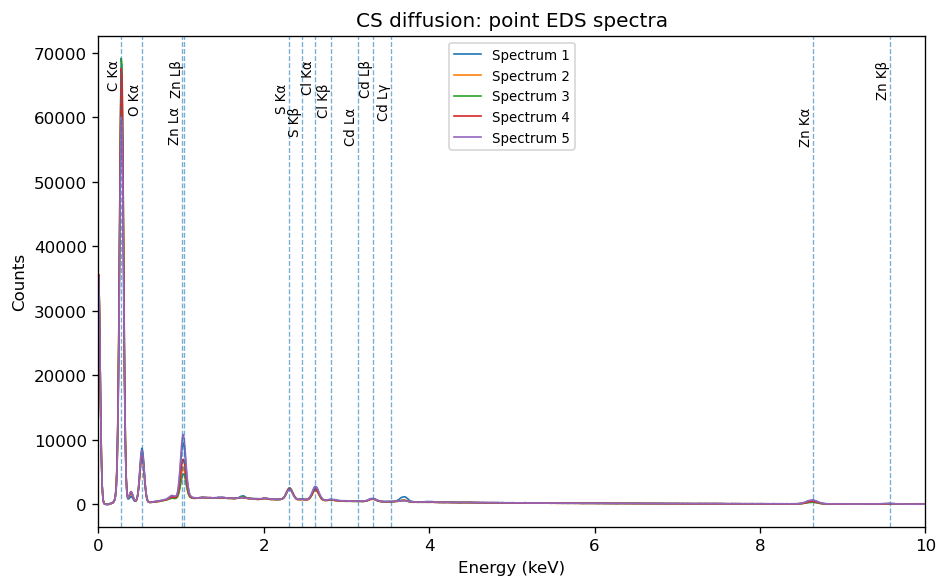

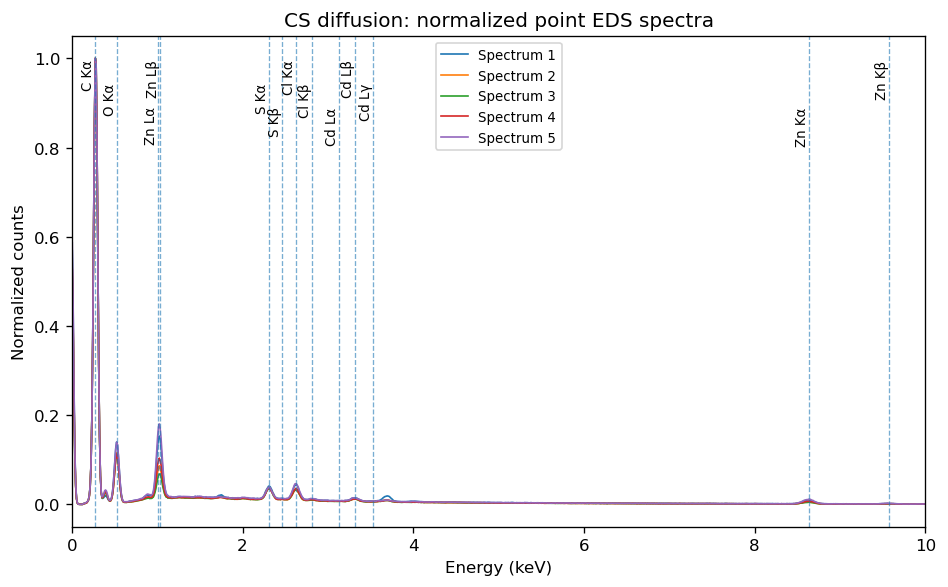

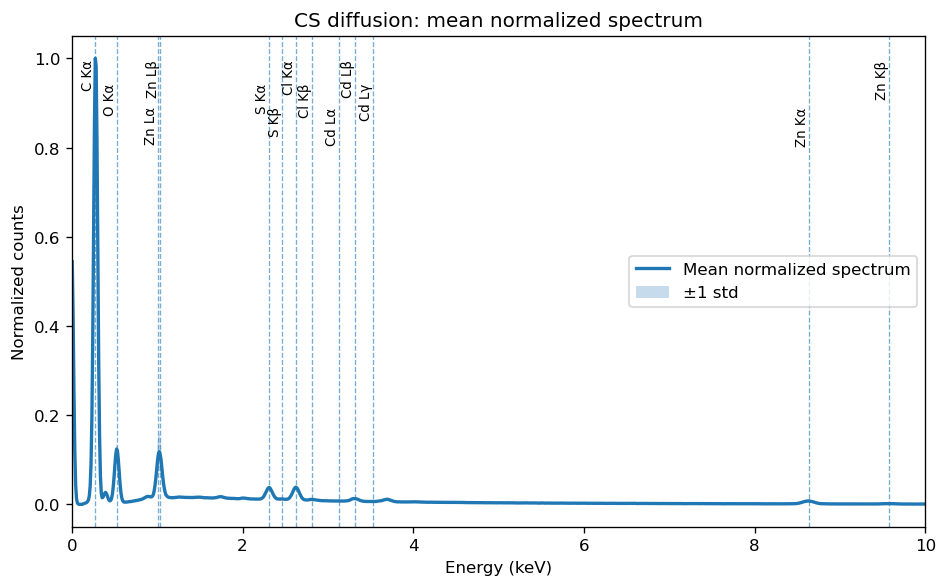


Processing folder: Gel and Bioplastic


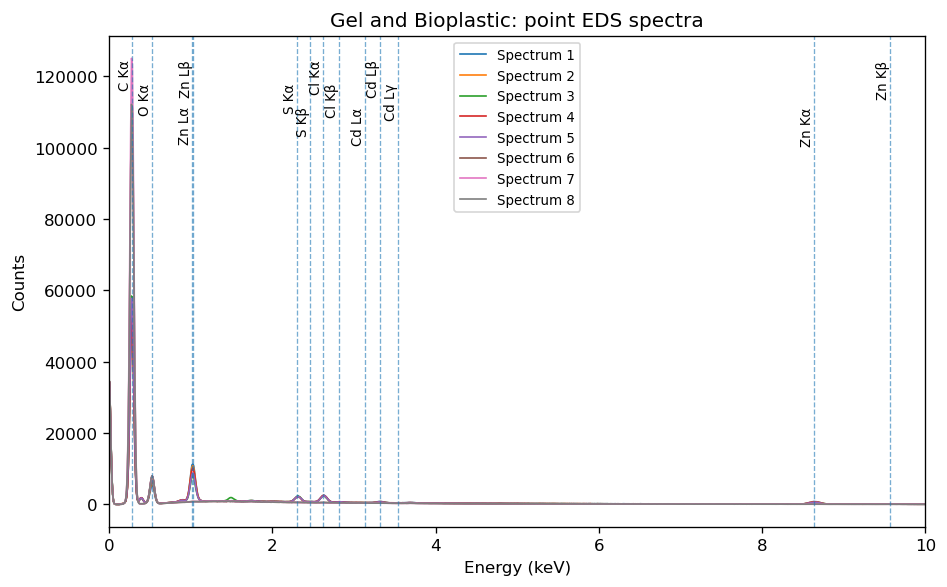

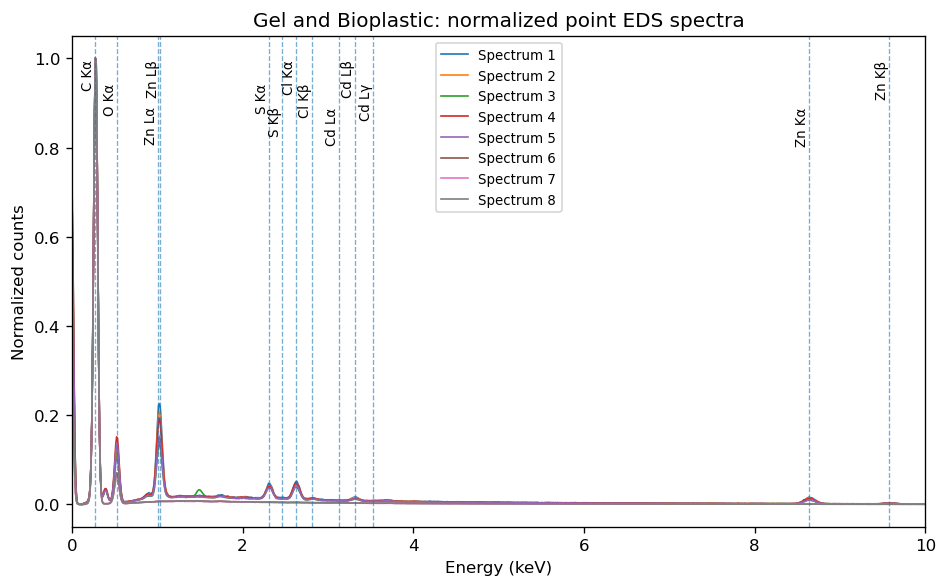

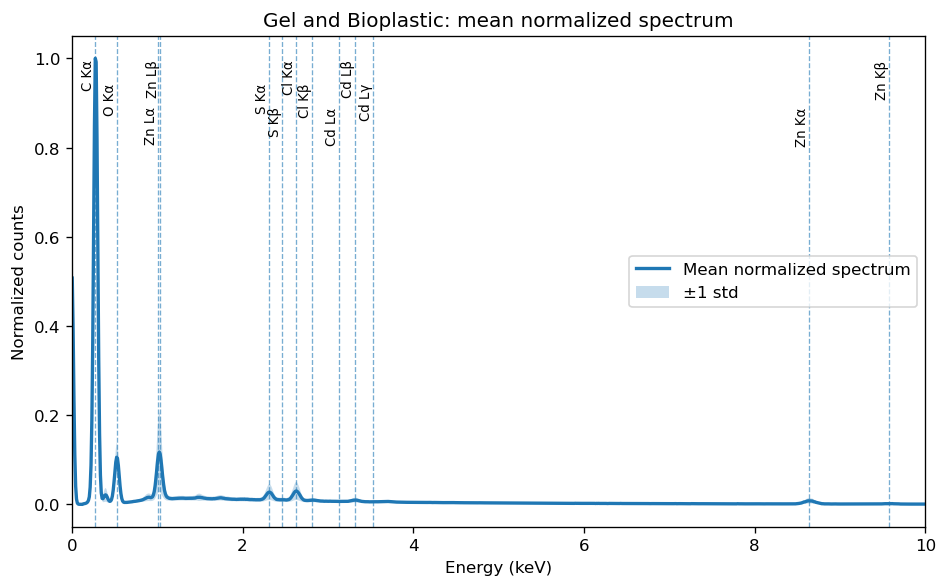


Processing folder: White and Red


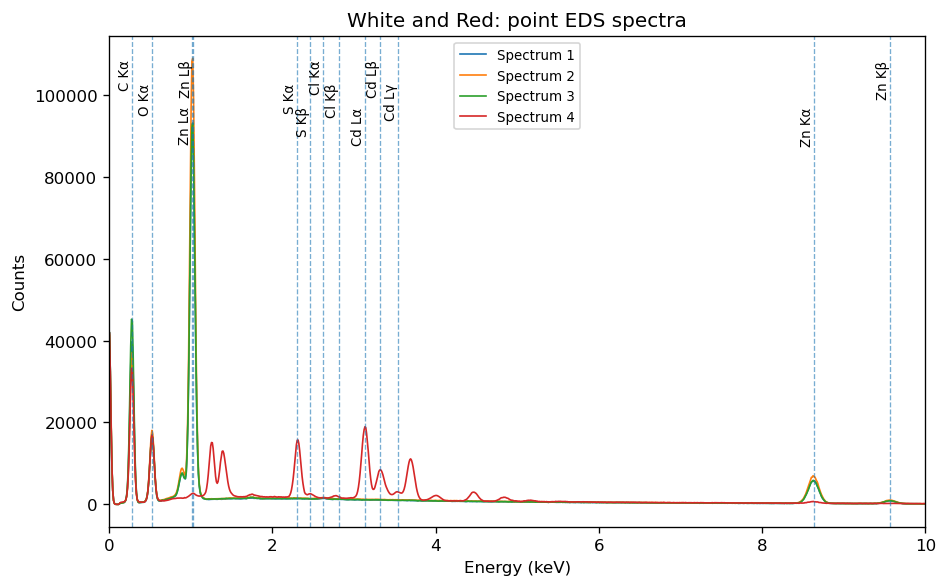

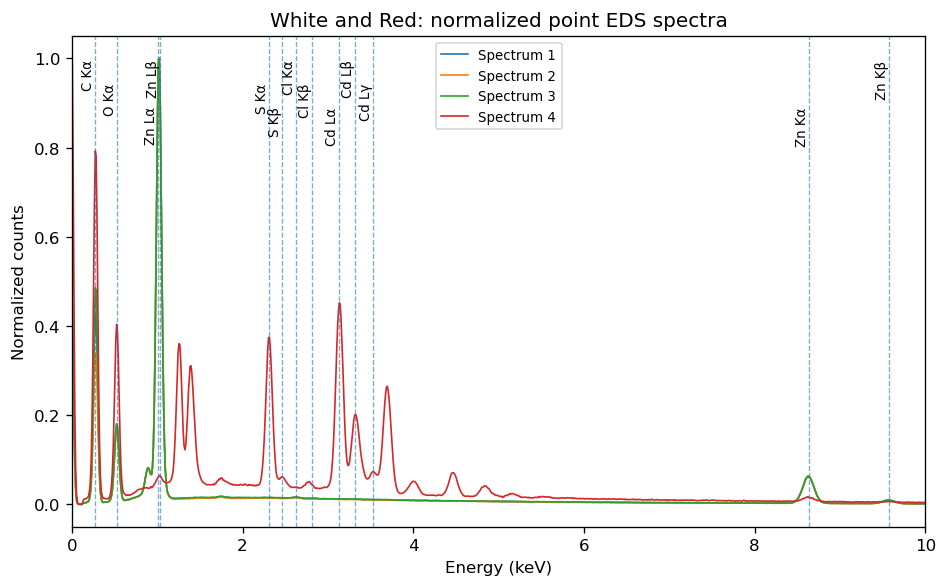

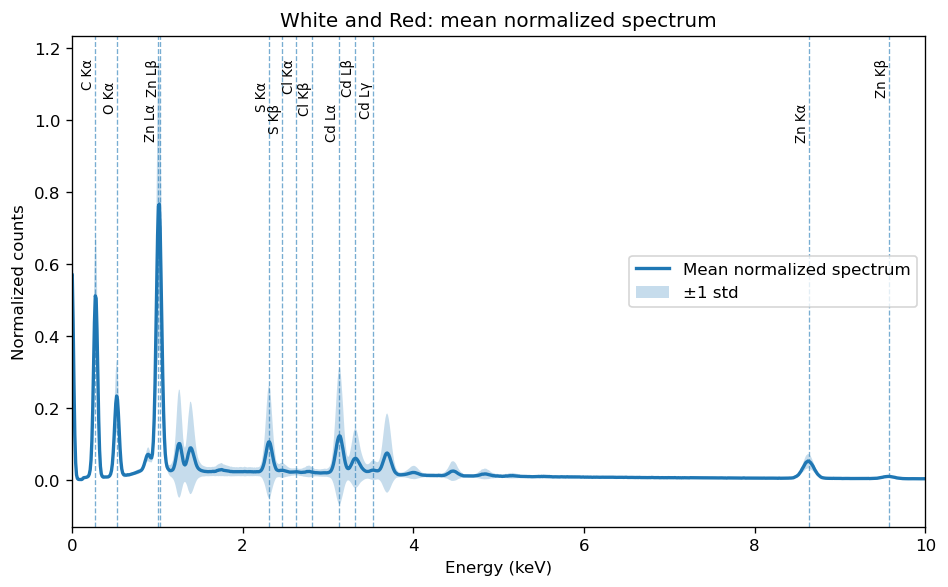


Done.
Processed spectra saved to: data_processed\point_scans
Figures saved to: data_processed\point_scans\figures
Summary table saved to: data_processed\point_scans\point_scan_summary.csv


,folder,file,n_channels,energy_min_keV,energy_max_keV,max_counts,processed_csv
0,CS diffusion,Spectrum 1.msa,2162,-0.955005,20.652834,62282.0,data_processed\point_scans\cs_diffusion\Spectr...
1,CS diffusion,Spectrum 2.msa,2002,-0.955005,19.052994,66813.0,data_processed\point_scans\cs_diffusion\Spectr...
2,CS diffusion,Spectrum 3.msa,1743,-0.955005,16.463253,69122.0,data_processed\point_scans\cs_diffusion\Spectr...
3,CS diffusion,Spectrum 4.msa,1896,-0.955005,17.993100,67526.0,data_processed\point_scans\cs_diffusion\Spectr...
4,CS diffusion,Spectrum 5.msa,2101,-0.955005,20.042895,60023.0,data_processed\point_scans\cs_diffusion\Spectr...
5,Gel and Bioplastic,Spectrum 1.msa,1669,-0.955682,15.730990,49999.0,data_processed\point_scans\gel_and_bioplastic\...
6,Gel and Bioplastic,Spectrum 2.msa,2096,-0.955682,20.002698,52246.0,data_processed\point_scans\gel_and_bioplastic\...
7,Gel and Bioplastic,Spectrum 3.msa,1792,-0.955682,16.961482,58403.0,data_processed\point_scans\gel_and_bioplastic\...
8,Gel and Bioplastic,Spectrum 4.msa,2135,-0.955682,20.392854,52596.0,data_processed\point_scans\gel_and_bioplastic\...
9,Gel and Bioplastic,Spectrum 5.msa,2014,-0.955682,19.182370,57734.0,data_processed\point_scans\gel_and_bioplastic\...


In [46]:
# Process raw .msa files to CSV
all_summary = []

for folder in FOLDERS:
    folder_path = RAW_BASE / folder
    out_folder = OUT_BASE / folder.lower().replace(" ", "_")
    out_folder.mkdir(parents=True, exist_ok=True)

    msa_files = sorted(folder_path.glob("*.msa"))
    if not msa_files:
        print(f"No .msa files found in: {folder_path}")
        continue

    spectra = []

    print(f"\nProcessing folder: {folder}")

    for f in msa_files:
        x, counts, meta, calibrated = read_msa(f)

        if not calibrated:
            print(f"Could not calibrate: {f.name}")
            continue

        counts_norm = normalize_spectrum(counts)

        out_csv = out_folder / f"{f.stem}.csv"
        save_processed_csv(out_csv, x, counts, counts_norm)

        spectra.append({
            "name": f.stem,
            "x": x,
            "counts": counts,
            "counts_norm": counts_norm,
            "meta": meta
        })

        all_summary.append({
            "folder": folder,
            "file": f.name,
            "n_channels": len(counts),
            "energy_min_keV": float(x.min()),
            "energy_max_keV": float(x.max()),
            "max_counts": float(counts.max()),
            "processed_csv": str(out_csv)
        })

    if len(spectra) == 0:
        print(f"Warning: no calibrated spectra found in folder {folder}. Skipping.")
        continue

    plot_folder_spectra(folder, spectra, FIG_DIR, xlim=(0, 10))

summary_df = pd.DataFrame(all_summary)
summary_csv = OUT_BASE / "point_scan_summary.csv"
summary_df.to_csv(summary_csv, index=False)

print("\nDone.")
print(f"Processed spectra saved to: {OUT_BASE}")
print(f"Figures saved to: {FIG_DIR}")
print(f"Summary table saved to: {summary_csv}")

summary_df

In [47]:
# Helper: read processed CSV spectra
def load_processed_folder(folder_slug):
    folder_path = OUT_BASE / folder_slug
    csv_files = sorted(folder_path.glob("*.csv"))
    spectra = []

    for f in csv_files:
        df = pd.read_csv(f)

        energy_col = [c for c in df.columns if "Energy" in c][0]
        energy = df[energy_col].to_numpy()
        counts = df["Counts"].to_numpy()
        counts_norm = df["Counts_norm_max1"].to_numpy()

        spectra.append({
            "name": f.stem,
            "energy": energy,
            "counts": counts,
            "counts_norm": counts_norm,
            "path": f
        })

    return spectra


def common_grid_mean_std(spectra):
    e_min = max(s["energy"].min() for s in spectra)
    e_max = min(s["energy"].max() for s in spectra)

    if e_max <= e_min:
        raise ValueError("No overlapping energy range among spectra.")

    min_step = min(np.min(np.diff(s["energy"])) for s in spectra if len(s["energy"]) > 1)
    energy_common = np.arange(e_min, e_max, min_step)

    stack = []
    for s in spectra:
        y = np.interp(energy_common, s["energy"], s["counts_norm"])
        stack.append(y)

    stack = np.vstack(stack)
    mean_spec = stack.mean(axis=0)
    std_spec = stack.std(axis=0)

    return energy_common, mean_spec, std_spec, stack


def window_area(energy, y, emin, emax):
    mask = (energy >= emin) & (energy <= emax)
    if not np.any(mask):
        return 0.0
    return np.trapz(y[mask], energy[mask])

# 3. Separation of White and Red Spectra

Spectra from the "White and Red" dataset were separated into zinc-white-like and cadmium-red-like groups based on integrated peak intensities.

Classification criteria:
- zinc-white-like: dominant Zn (K and L) emission
- cadmium-red-like: dominant Cd and S emission

In [48]:
# Split White and Red folder automatically
def classify_white_red_spectra(spectra):
    """
    Simple chemistry-based split:
    - zinc-white-like if Zn dominates and Cd/S are weak
    - cadmium-red-like if Cd/S dominate
    """
    white_like = []
    red_like = []
    summary = []

    for s in spectra:
        e = s["energy"]
        y = s["counts_norm"]

        zn = window_area(e, y, 8.45, 8.85)     # Zn Kα region
        cd = window_area(e, y, 3.00, 3.40)     # Cd Lα/Lβ region
        sulfur = window_area(e, y, 2.22, 2.40) # S Kα region

        pigment_score = cd + sulfur

        if zn > pigment_score:
            group = "zinc-white-like"
            white_like.append(s)
        else:
            group = "cadmium-red-like"
            red_like.append(s)

        summary.append({
            "spectrum": s["name"],
            "Zn_area": zn,
            "Cd_area": cd,
            "S_area": sulfur,
            "group": group
        })

    return white_like, red_like, pd.DataFrame(summary)

# 4. ROI-Based Spectral Comparison

Representative point spectra are shown alongside ROI images to provide spatial context for each region.

In [49]:
# Optional ROI image loading
def load_image_or_none(path):
    if path is None or not path.exists():
        return None
    try:
        return np.array(Image.open(path))
    except Exception:
        return None


roi_cs_path = RAW_BASE / "CS diffusion ROI.tif"
roi_gel_path = RAW_BASE / "Gel and Bioplastic ROI.tif"
roi_wr_path = RAW_BASE / "White1to3 and Red4.tif"

print("CS diffusion ROI:", roi_cs_path.exists(), roi_cs_path)
print("Gel and Bioplastic ROI:", roi_gel_path.exists(), roi_gel_path)
print("White and Red ROI:", roi_wr_path.exists(), roi_wr_path)

roi_cs = load_image_or_none(roi_cs_path)
roi_gel = load_image_or_none(roi_gel_path)
roi_wr = load_image_or_none(roi_wr_path)

CS diffusion ROI: True data_raw\Point Scans\CS diffusion ROI.tif
Gel and Bioplastic ROI: True data_raw\Point Scans\Gel and Bioplastic ROI.tif
White and Red ROI: True data_raw\Point Scans\White1to3 and Red4.tif


In [50]:
def add_element_lines_plot(ax, ymax, xlim=(0, 10)):
    for i, (label, xpos) in enumerate({
        "C Kα": 0.277,
        "O Kα": 0.525,
        "Zn Lα": 1.012,
        "S Kα": 2.307,
        "Cl Kα": 2.622,
        "Cd Lα": 3.133,
        "Zn Kα": 8.638,
        "Zn Kβ": 9.572,
    }.items()):
        if xlim[0] <= xpos <= xlim[1]:
            ax.axvline(xpos, linestyle="--", linewidth=0.8, alpha=0.5)
            ax.text(
                xpos,
                ymax * (0.97 - 0.05 * (i % 3)),
                label,
                rotation=90,
                va="top",
                ha="right",
                fontsize=7
            )


def plot_group(ax, spectra, title, xlim=(0, 10), show_individual=True):
    if len(spectra) == 0:
        ax.text(0.5, 0.5, "No spectra available", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        ax.set_xlim(*xlim)
        return

    energy_common, mean_spec, std_spec, stack = common_grid_mean_std(spectra)

    if show_individual:
        for s in spectra:
            ax.plot(s["energy"], s["counts_norm"], linewidth=1, alpha=0.45)

    ax.plot(energy_common, mean_spec, linewidth=2.5, label="Mean")
    ax.fill_between(
        energy_common,
        mean_spec - std_spec,
        mean_spec + std_spec,
        alpha=0.20,
        label="±1 std"
    )

    ax.set_title(title)
    ax.set_xlabel("Energy (keV)")
    ax.set_ylabel("Normalized counts")
    ax.set_xlim(*xlim)
    ymax = ax.get_ylim()[1]
    add_element_lines_plot(ax, ymax, xlim=xlim)

In [52]:
# Load processed spectra
cs_specs = load_processed_folder("cs_diffusion")
gel_specs = load_processed_folder("gel_and_bioplastic")
wr_specs = load_processed_folder("white_and_red")

white_like, red_like, wr_summary = classify_white_red_spectra(wr_specs)
wr_summary

,spectrum,Zn_area,Cd_area,S_area,group
0,Spectrum 1,0.010722,0.004573,0.002531,zinc-white-like
1,Spectrum 2,0.010877,0.004364,0.002378,zinc-white-like
2,Spectrum 3,0.010700,0.004691,0.002606,zinc-white-like
3,Spectrum 4,0.004063,0.076298,0.037707,cadmium-red-like


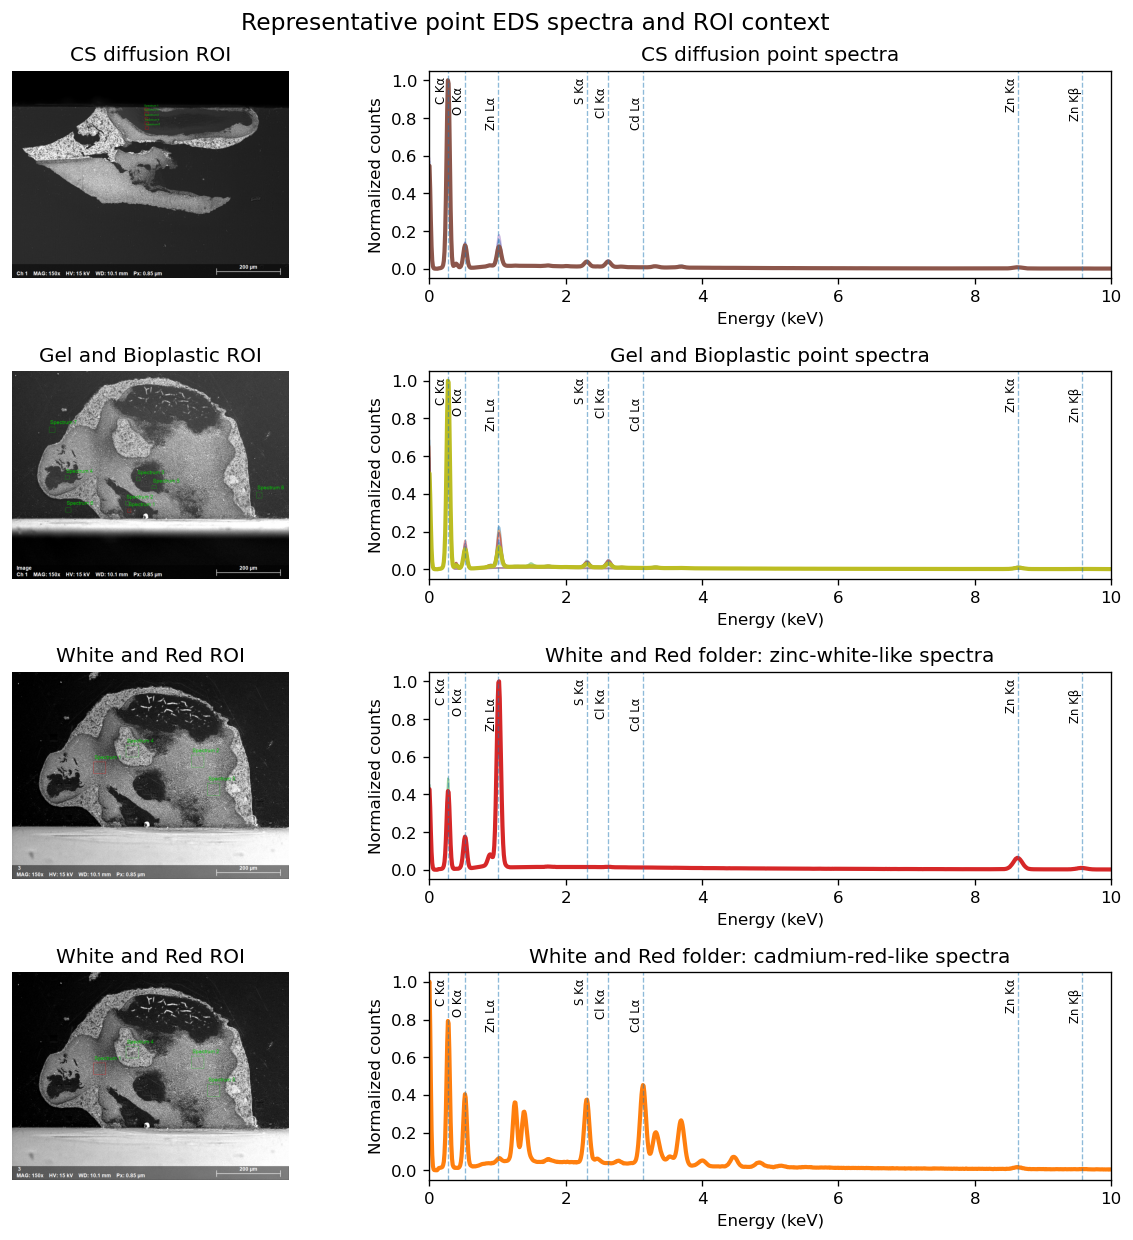

Saved figure to: data_processed\point_scans\figures\publication_style_point_spectra_figure.png


In [53]:
# Make figure
fig = plt.figure(figsize=(12, 11))
gs = GridSpec(4, 2, figure=fig, width_ratios=[1, 2.2], hspace=0.45, wspace=0.25)

# Row 1: CS diffusion
ax_img1 = fig.add_subplot(gs[0, 0])
ax_sp1 = fig.add_subplot(gs[0, 1])

if roi_cs is not None:
    ax_img1.imshow(roi_cs, cmap="magma")
    ax_img1.set_title("CS diffusion ROI")
else:
    ax_img1.text(0.5, 0.5, "CS diffusion ROI\nnot found", ha="center", va="center", transform=ax_img1.transAxes)
ax_img1.axis("off")

plot_group(ax_sp1, cs_specs, "CS diffusion point spectra", xlim=(0, 10), show_individual=True)

# Row 2: Gel and Bioplastic
ax_img2 = fig.add_subplot(gs[1, 0])
ax_sp2 = fig.add_subplot(gs[1, 1])

if roi_gel is not None:
    ax_img2.imshow(roi_gel, cmap="magma")
    ax_img2.set_title("Gel and Bioplastic ROI")
else:
    ax_img2.text(0.5, 0.5, "Gel and Bioplastic ROI\nnot found", ha="center", va="center", transform=ax_img2.transAxes)
ax_img2.axis("off")

plot_group(ax_sp2, gel_specs, "Gel and Bioplastic point spectra", xlim=(0, 10), show_individual=True)

# Row 3: White-like
ax_img3 = fig.add_subplot(gs[2, 0])
ax_sp3 = fig.add_subplot(gs[2, 1])

if roi_wr is not None:
    ax_img3.imshow(roi_wr, cmap="magma")
    ax_img3.set_title("White and Red ROI")
else:
    ax_img3.text(0.5, 0.5, "White and Red ROI\nnot found", ha="center", va="center", transform=ax_img3.transAxes)
ax_img3.axis("off")

plot_group(ax_sp3, white_like, "White and Red folder: zinc-white-like spectra", xlim=(0, 10), show_individual=True)

# Row 4: Red-like
ax_img4 = fig.add_subplot(gs[3, 0])
ax_sp4 = fig.add_subplot(gs[3, 1])

if roi_wr is not None:
    ax_img4.imshow(roi_wr, cmap="magma")
    ax_img4.set_title("White and Red ROI")
else:
    ax_img4.text(0.5, 0.5, "White and Red ROI\nnot found", ha="center", va="center", transform=ax_img4.transAxes)
ax_img4.axis("off")

plot_group(ax_sp4, red_like, "White and Red folder: cadmium-red-like spectra", xlim=(0, 10), show_individual=True)

fig.suptitle("Representative point EDS spectra and ROI context", fontsize=14, y=0.995)
fig.subplots_adjust(top=0.95, hspace=0.5, wspace=0.25)

out_png = FIG_DIR / "publication_style_point_spectra_figure.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {out_png}")